In [97]:
import time
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import schwabdev as sd
import time as tm
import zarr
import shutil
import os

import warnings

warnings.filterwarnings('ignore', message="The data type .* does not have a Zarr V3 specification.*")
warnings.filterwarnings('ignore', message="Consolidated metadata is currently not part in the Zarr format 3 specification.*")

from main_classes.Save_Data_Master import Save_Data_Master as SDM
from utility.lib_apiManagment import create_client as CC

In [43]:
sdm = SDM()

In [120]:
zarr_store = xr.open_dataset(sdm.hot_path_master)
zarr_store

<xarray.Dataset> Size: 2GB
Dimensions:  (day: 4, time: 288, ident: 5546, qVar: 36, fVar: 18)
Coordinates:
  * fVar     (fVar) <U28 2kB 'assetSubType' 'ssid' ... 'quote.closePrice'
  * qVar     (qVar) <U29 4kB 'reference.htbRate' ... 'quote.postMarketPercent...
  * day      (day) <U10 160B '2025-08-31' '2025-09-01' '2025-09-02' '2025-09-03'
  * time     (time) <U5 6kB '00:00' '00:05' '00:10' ... '23:45' '23:50' '23:55'
  * ident    (ident) <U7 155kB 'A' 'AA' 'AACB' 'AACI' ... 'ZYBT' 'ZYME' 'ZYXI'
Data variables:
    5m       (day, time, ident, qVar) float64 2GB ...
    1d       (day, ident, fVar) float64 3MB ...

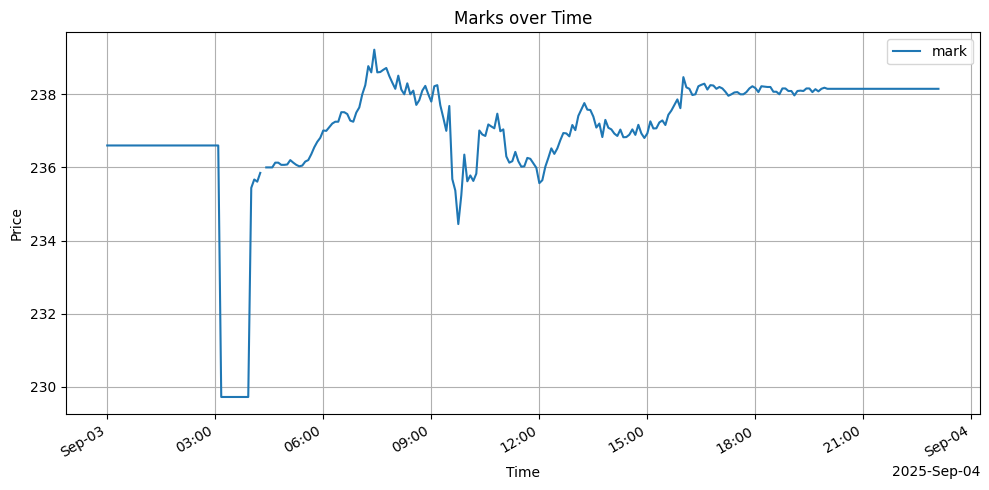

In [121]:
STOCK = 'AAPL'
DAY = '2025-09-03'

stock_marks = zarr_store['5m'].sel(ident=STOCK,day=DAY,qVar='quote.mark')
stock_marks['time'] = datetimes = pd.to_datetime(DAY + ' ' + stock_marks['time'].values)

plt.figure(figsize=(10,5))
stock_marks.plot(label='mark')

plt.title("Marks over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate() # Rotate labels for readability
plt.tight_layout()
plt.show()

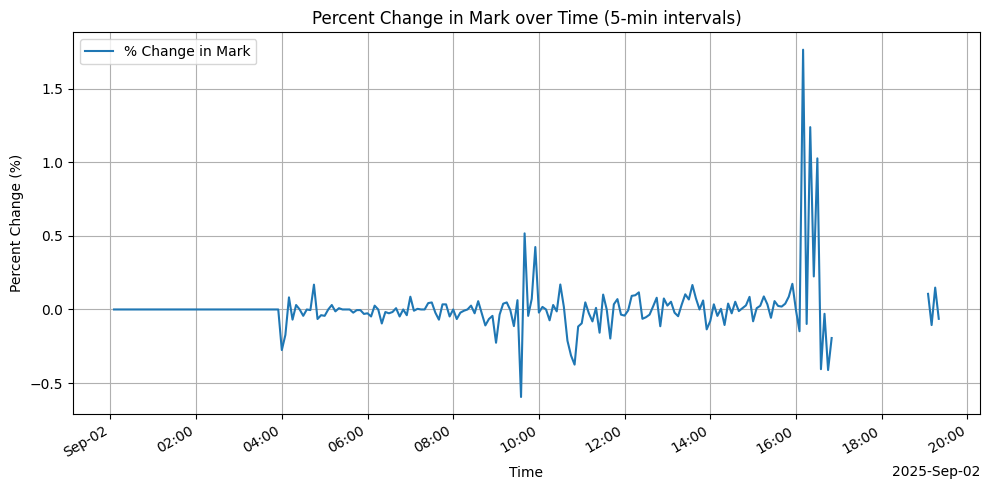

In [91]:
STOCK = 'AAPL'
DAY = '2025-09-02'
stock_marks = zarr_store['5m'].sel(ident=STOCK, day=DAY, qVar='quote.mark')
stock_marks['time'] = pd.to_datetime(DAY + ' ' + stock_marks['time'].values)

# Calculate percent change for each 5-minute interval using xarray operations
percent_change = (stock_marks.diff('time') / stock_marks.shift(time=1)) * 100

plt.figure(figsize=(10, 5))
percent_change.plot(label='% Change in Mark')
plt.title("Percent Change in Mark over Time (5-min intervals)")
plt.xlabel("Time")
plt.ylabel("Percent Change (%)")
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()  # Rotate labels for readability
plt.tight_layout()
plt.show()

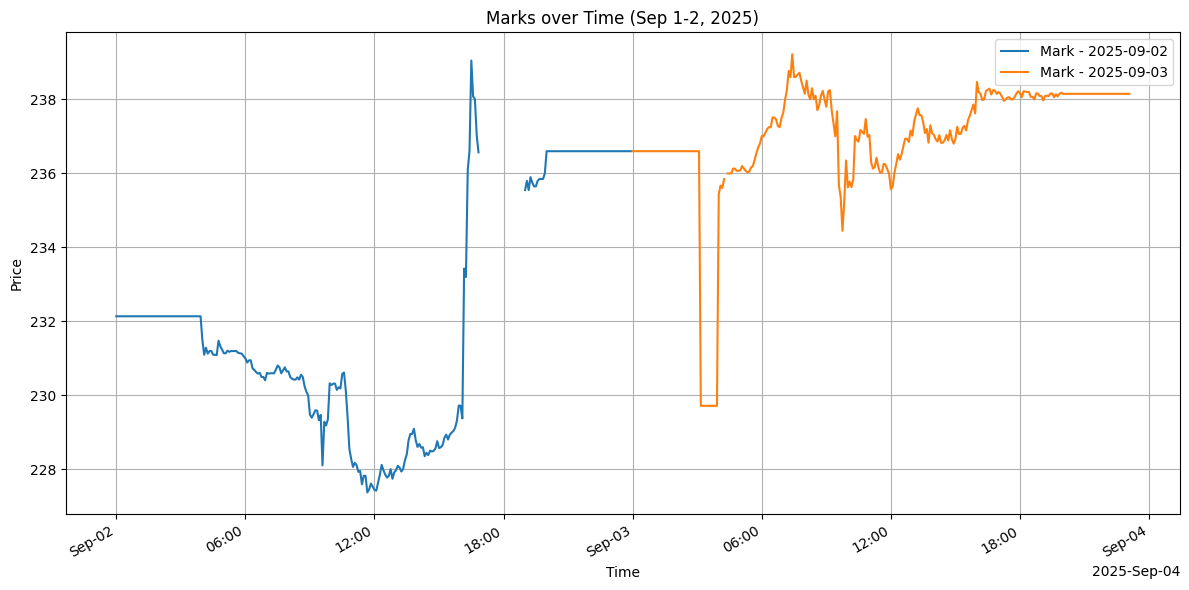

In [122]:
STOCK = 'AAPL'
DAYS = ['2025-09-02', '2025-09-03']

plt.figure(figsize=(12, 6))

for day in DAYS:
    stock_marks = zarr_store['5m'].sel(ident=STOCK, day=day, qVar='quote.mark')
    stock_marks['time'] = pd.to_datetime(day + ' ' + stock_marks['time'].values)
    stock_marks.plot(label=f'Mark - {day}')

plt.title("Marks over Time (Sep 1-2, 2025)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()  # Rotate labels for readability
plt.tight_layout()
plt.show()

<Figure size 12000x600 with 0 Axes>

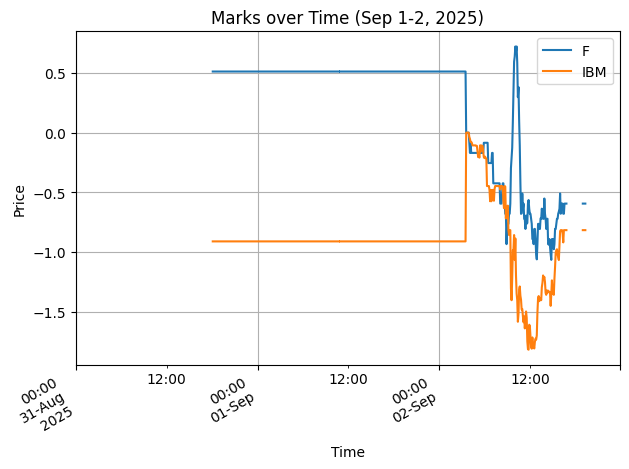

In [92]:
STOCK = ['F','IBM']
DAYS = ['2025-08-31','2025-09-01', '2025-09-02']

# Combine data from both days
all_data = []
for day in DAYS:
    stock_marks = zarr_store['5m'].sel(ident=STOCK, day=day, qVar='quote.markPercentChange')
    stock_marks['time'] = pd.to_datetime(day + ' ' + stock_marks['time'].values)
    # Convert to pandas Series with time as index
    pandas_series = stock_marks.to_pandas()
    all_data.append(pandas_series)

# Concatenate the data
combined_data = pd.concat(all_data).sort_index()

plt.figure(figsize=(120, 6))
combined_data.plot(label='mark')

plt.title("Marks over Time (Sep 1-2, 2025)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()  # Rotate labels for readability
plt.tight_layout()
plt.show()

<Figure size 1500x600 with 0 Axes>

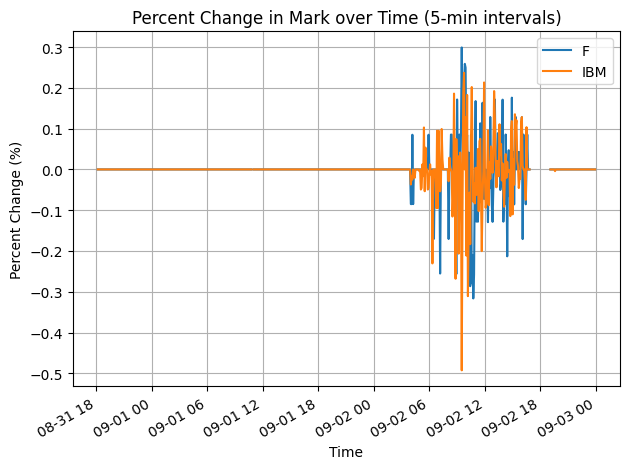

In [124]:
STOCKS = ['F', 'IBM']
DAYS = ['2025-08-31', '2025-09-01', '2025-09-02']

# Combine data from all stocks and days
stock_data = {}
for stock in STOCKS:
    daily_data = []
    for day in DAYS:
        stock_marks = zarr_store['5m'].sel(ident=stock, day=day, qVar='quote.mark')
        stock_marks['time'] = pd.to_datetime(day + ' ' + stock_marks['time'].values)
        
        # Calculate percent change for each 5-minute interval
        percent_change = (stock_marks.diff('time') / stock_marks.shift(time=1)) * 100
        
        # Convert to pandas Series with time as index
        pandas_series = percent_change.to_pandas()
        daily_data.append(pandas_series)
    
    # Concatenate all days for this stock
    stock_data[stock] = pd.concat(daily_data).sort_index()

# Combine all stocks into one DataFrame
combined_data = pd.DataFrame(stock_data)

plt.figure(figsize=(15, 6))
combined_data.plot()
plt.title("Percent Change in Mark over Time (5-min intervals)")
plt.xlabel("Time")
plt.ylabel("Percent Change (%)")
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [98]:
client = CC()

In [117]:
client.instruments('FOUR/P',"search").json()

{}

/tmp/ipykernel_462078/3993766027.py:8: FutureWarning: updating coordinate 'datetime', which is a PandasMultiIndex, would leave the multi-index level coordinates ['day', 'time'] in an inconsistent state. This will raise an error in the future. Use `.drop_vars(['datetime', 'day', 'time'])` to drop the coordinates' values before assigning new coordinate values.
  stock_marks['datetime'] =  pd.to_datetime([f"{day} {time}" for day, time in stock_marks['datetime'].values])


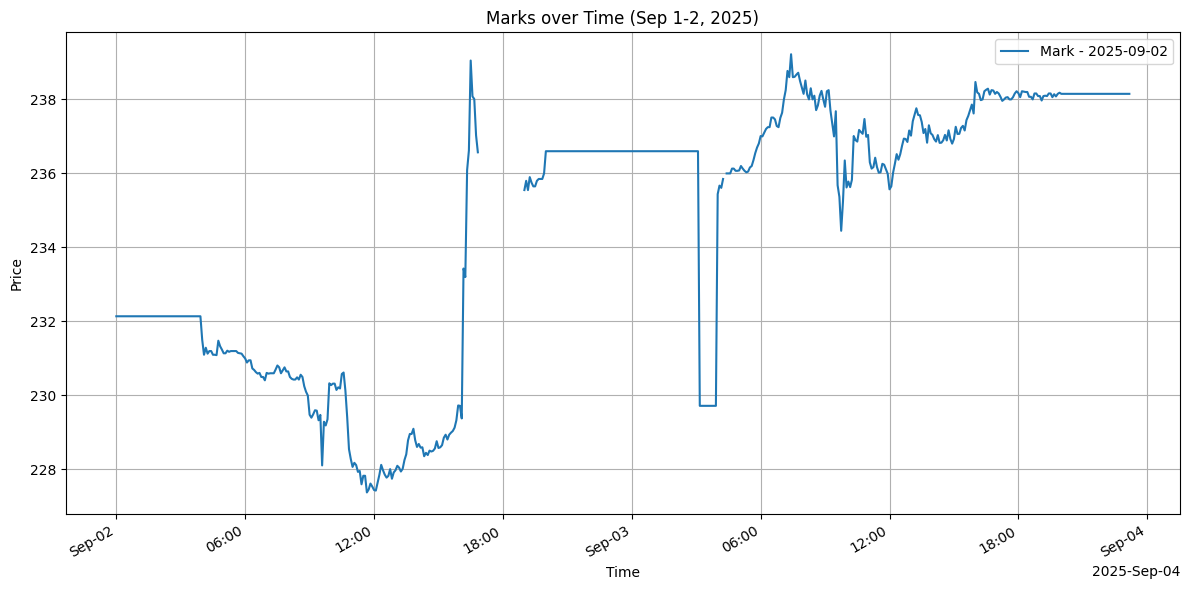

In [130]:
STOCK = 'AAPL'
DAYS = ['2025-09-02', '2025-09-03']

plt.figure(figsize=(12, 6))

stock_marks = zarr_store['5m'].sel(ident=STOCK, day=DAYS, qVar='quote.mark')
stock_marks = stock_marks.stack(datetime=('day','time'))
stock_marks['datetime'] =  pd.to_datetime([f"{day} {time}" for day, time in stock_marks['datetime'].values])
stock_marks.plot(label=f'Mark - {day}')

plt.title("Marks over Time (Sep 1-2, 2025)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()  # Rotate labels for readability
plt.tight_layout()
plt.show()